In [1]:
# %% [markdown]
# # Credit Scoring Model Evaluation with XGBoost
# 
# **Comparison of three training strategies:**
# 1. Original imbalanced data → Default XGBoost
# 2. SMOTE‑balanced training data → Default XGBoost
# 3. cWGAN‑GP balanced data → **Optuna‑tuned XGBoost (5‑fold CV)**
# 
# **Classifier:** XGBoost
# **Evaluation metrics:** AUC, Recall, Precision, F1, Accuracy


In [2]:
# %%
%load_ext autoreload


In [3]:

%autoreload 2


In [4]:

# %% [markdown]
# ## 1. Imports and Setup

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from imblearn.over_sampling import SMOTE
import joblib
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add scripts folder to path
sys.path.append(os.path.abspath("../scripts"))

# Import custom training module
from train_xgboost import train_xgboost_default, train_xgboost_optuna
from explainability import shap_explain, shap_waterfall_plot
from evaluation import (
    evaluate_classifier,
    compare_all_models,
    shap_evaluation,
    nested_cv_evaluation,
    friedman_test,
    wilcoxon_test
)

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


In [5]:

# %% [markdown]
# ## 2. Load Datasets

# %%
# Load imbalanced original data (one‑hot encoded)
df_imb = pd.read_csv("../data/processed/german_processed_onehot.csv")
print("Imbalanced data shape:", df_imb.shape)
print("Class counts:\n", df_imb['Class'].value_counts())

# Load cWGAN‑GP balanced data
df_gan = pd.read_csv("../data/processed/german_balanced_cwgan_improved.csv")
print("\ncWGAN‑GP balanced data shape:", df_gan.shape)
print("Class counts:\n", df_gan['Class'].value_counts())

target_col = 'Class'


Imbalanced data shape: (1000, 77)
Class counts:
 Class
0    700
1    300
Name: count, dtype: int64

cWGAN‑GP balanced data shape: (1400, 77)
Class counts:
 Class
0    700
1    700
Name: count, dtype: int64


In [6]:

# %% [markdown]
# ## 3. Split Imbalanced Data (70% train / 30% test)

# %%
X = df_imb.drop(columns=[target_col])
y = df_imb[target_col]

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train size: {X_train_imb.shape[0]}, Test size: {X_test_imb.shape[0]}")
print("Train class distribution:\n", y_train_imb.value_counts())
print("Test class distribution:\n", y_test_imb.value_counts())


Train size: 700, Test size: 300
Train class distribution:
 Class
0    490
1    210
Name: count, dtype: int64
Test class distribution:
 Class
0    210
1     90
Name: count, dtype: int64


In [7]:

# %% [markdown]
# ## 4. Prepare SMOTE‑Balanced Training Set

# %%
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imb, y_train_imb)

print("SMOTE balanced training set shape:", X_train_smote.shape)
print("SMOTE balanced class distribution:\n", pd.Series(y_train_smote).value_counts())


SMOTE balanced training set shape: (980, 76)
SMOTE balanced class distribution:
 Class
1    490
0    490
Name: count, dtype: int64


In [8]:

# %% [markdown]
# ## 5. Split cWGAN‑GP Balanced Data (70% train / 30% test)

# %%
X_gan = df_gan.drop(columns=[target_col])
y_gan = df_gan[target_col]

X_train_gan, X_test_gan, y_train_gan, y_test_gan = train_test_split(
    X_gan, y_gan, test_size=0.3, random_state=42, stratify=y_gan
)

print(f"Train size: {X_train_gan.shape[0]}, Test size: {X_test_gan.shape[0]}")
print("Train class distribution:\n", y_train_gan.value_counts())
print("Test class distribution:\n", y_test_gan.value_counts())


Train size: 980, Test size: 420
Train class distribution:
 Class
0    490
1    490
Name: count, dtype: int64
Test class distribution:
 Class
0    210
1    210
Name: count, dtype: int64


In [ ]:


# %% [markdown]
# ## 6. Train Models

# %%
# =====================================================================
# Model 1: Imbalanced Baseline (Default XGBoost)
# =====================================================================
print("\n" + "="*60)
print("MODEL 1: IMBALANCED BASELINE")
print("="*60)

best_imb = train_xgboost_default(
    X_train_imb.values, y_train_imb.values,
    X_test_imb.values, y_test_imb.values,
    scale_pos_weight=True
)




MODEL 1: IMBALANCED BASELINE
  Default XGBoost trained (scale_pos_weight=2.33)


In [10]:

# =====================================================================
# Model 2: SMOTE Baseline (Default XGBoost)
# =====================================================================
print("\n" + "="*60)
print("MODEL 2: SMOTE BASELINE")
print("="*60)

# Convert SMOTE output back to DataFrame with feature names
X_train_smote = pd.DataFrame(X_train_smote, columns=X_train_imb.columns)

best_smote = train_xgboost_default(
    X_train_smote.values, y_train_smote,
    X_test_imb.values, y_test_imb.values,
    scale_pos_weight=False
)



MODEL 2: SMOTE BASELINE
  Default XGBoost trained (scale_pos_weight=1.00)


In [11]:

# =====================================================================
# Model 3: cWGAN‑GP (Optuna‑tuned XGBoost with 5‑fold CV)
# =====================================================================
print("\n" + "="*60)
print("MODEL 3: cWGAN‑GP (PROPOSED)")
print("="*60)

best_gan, best_params_gan = train_xgboost_optuna(
    X_train_gan.values, y_train_gan.values,
    X_test_gan.values, y_test_gan.values,
    n_trials=50,
    cv_folds=5,
    random_state=42
)

# Save model for SHAP
joblib.dump(best_gan, '../models/xgb_cwgan_balanced.pkl')
print("\n✅ Model saved to ../models/xgb_cwgan_balanced.pkl")


[I 2026-04-24 16:01:55,651] A new study created in memory with name: no-name-feb7efbd-bcd9-4cdd-a20e-e74b3df451f8



MODEL 3: cWGAN‑GP (PROPOSED)

  Starting Optuna hyperparameter optimization
  Trials: 50, CV folds: 5


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-24 16:01:55,846] Trial 0 finished with value: 0.8354643898375678 and parameters: {'n_estimators': 144, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 8.661761457749352, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 0.8354643898375678.
[I 2026-04-24 16:01:56,001] Trial 1 finished with value: 0.8373386089129531 and parameters: {'n_estimators': 227, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 3.0424224295953772, 'reg_lambda': 5.247564316322379}. Best is trial 1 with value: 0.8373386089129531.
[I 2026-04-24 16:01:56,144] Trial 2 finished with value: 0.810204081632653 and parameters: {'n_estimators': 158, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'subsample': 0.6557


Imbalanced Performance
AUC-ROC: 0.8060
Recall: 0.6000
Precision: 0.5934
F1-score: 0.5967
Accuracy: 0.7567


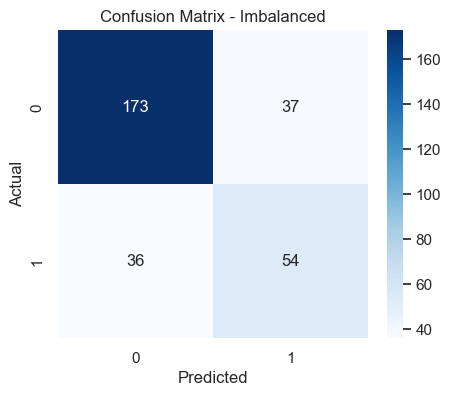

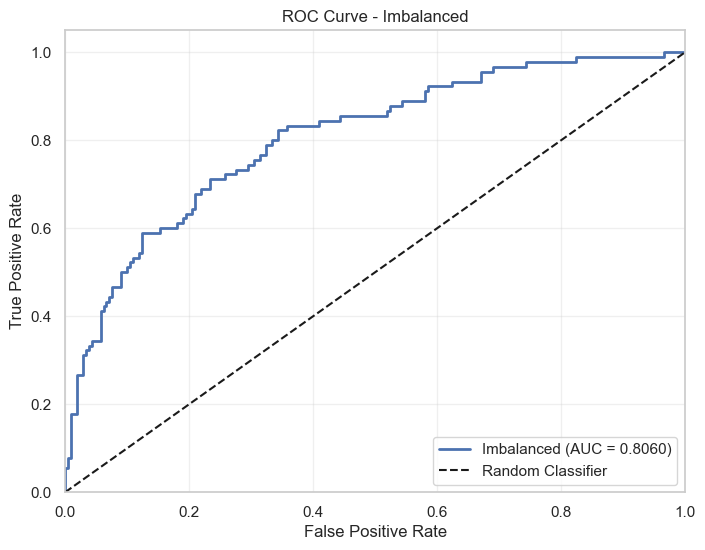


SMOTE Performance
AUC-ROC: 0.7892
Recall: 0.5111
Precision: 0.6479
F1-score: 0.5714
Accuracy: 0.7700


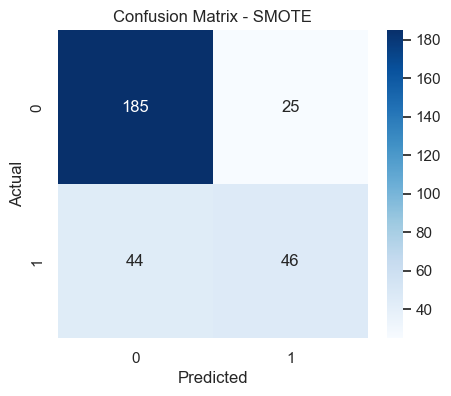

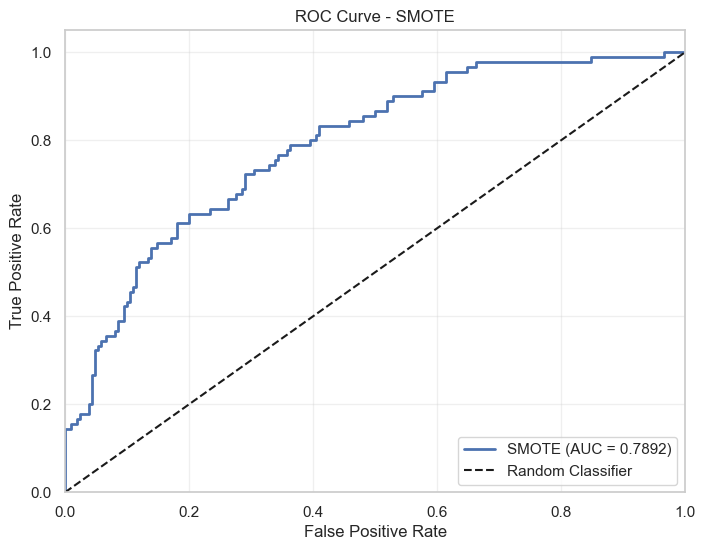


cWGAN-GP (Optuna) Performance
AUC-ROC: 0.8835
Recall: 0.7762
Precision: 0.8109
F1-score: 0.7932
Accuracy: 0.7976


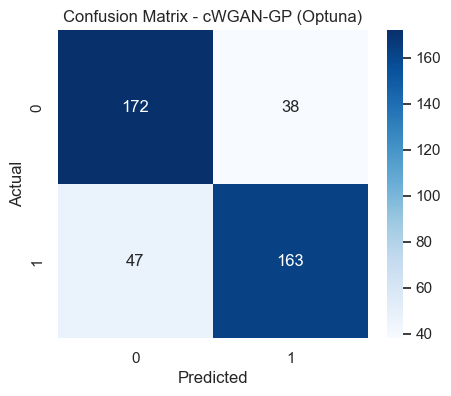

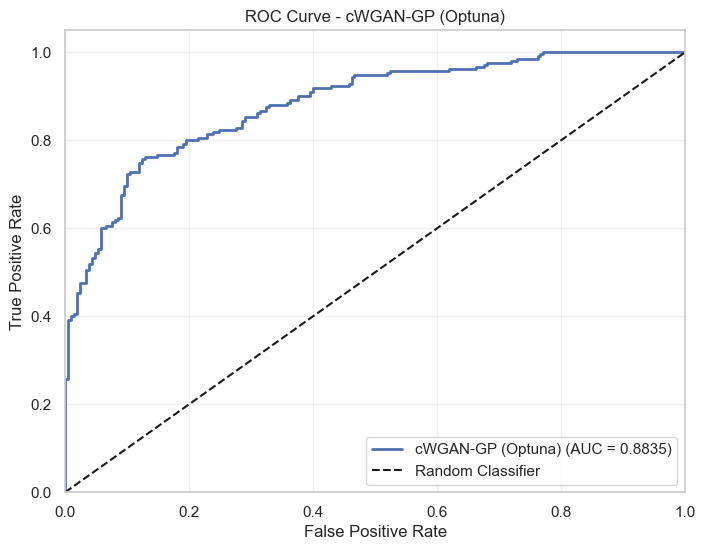


FINAL COMPARISON TABLE
                   AUC-ROC  Recall  Precision  F1-score  Accuracy
Model                                                            
Imbalanced          0.8060  0.6000     0.5934    0.5967    0.7567
SMOTE               0.7892  0.5111     0.6479    0.5714    0.7700
cWGAN-GP (Optuna)   0.8835  0.7762     0.8109    0.7932    0.7976


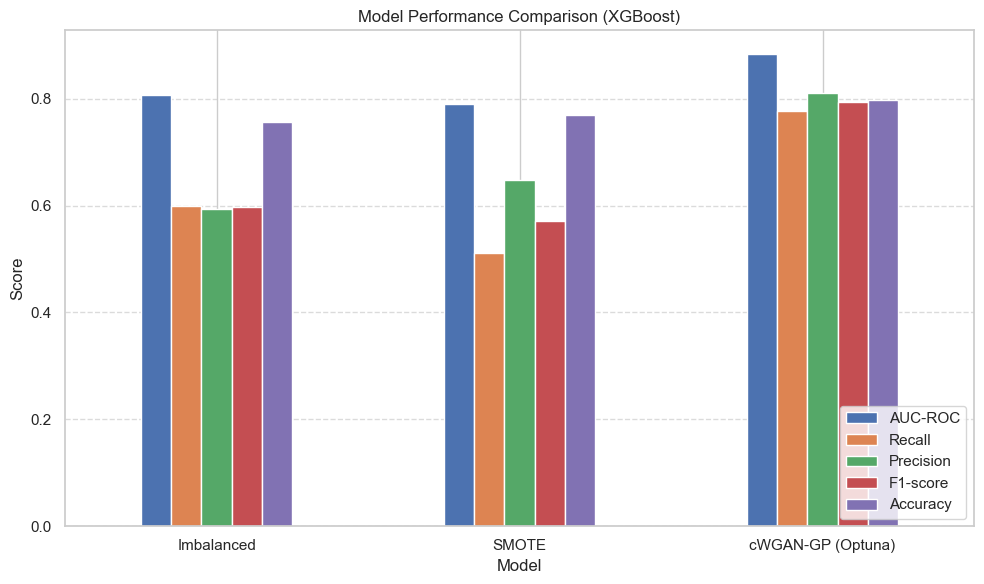

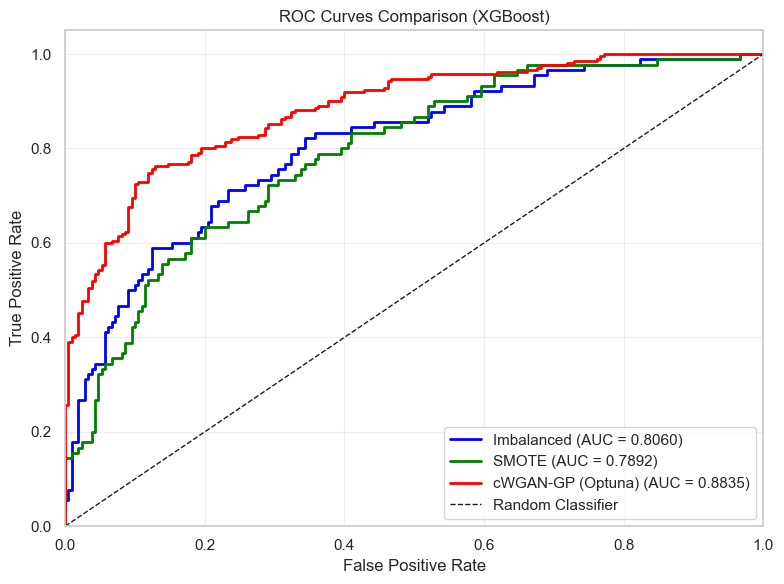

In [13]:

# %% [markdown]
# ## 7. Evaluate All Models

# %%
# Build models dictionary for comparison
models_dict = {
    'Imbalanced': (best_imb, X_test_imb, y_test_imb),
    'SMOTE': (best_smote, X_test_imb, y_test_imb),
    'cWGAN-GP (Optuna)': (best_gan, X_test_gan, y_test_gan)
}

# Run comprehensive comparison
results_df = compare_all_models(models_dict)


In [14]:

# %% [markdown]
# ## 8. Detailed Classification Reports

# %%
print("\nImbalanced Model - Classification Report:")
print(classification_report(y_test_imb, best_imb.predict(X_test_imb), target_names=['Good', 'Bad']))

print("\nSMOTE Model - Classification Report:")
print(classification_report(y_test_imb, best_smote.predict(X_test_imb), target_names=['Good', 'Bad']))

print("\ncWGAN‑GP Model - Classification Report:")
print(classification_report(y_test_gan, best_gan.predict(X_test_gan), target_names=['Good', 'Bad']))



Imbalanced Model - Classification Report:
              precision    recall  f1-score   support

        Good       0.83      0.82      0.83       210
         Bad       0.59      0.60      0.60        90

    accuracy                           0.76       300
   macro avg       0.71      0.71      0.71       300
weighted avg       0.76      0.76      0.76       300


SMOTE Model - Classification Report:
              precision    recall  f1-score   support

        Good       0.81      0.88      0.84       210
         Bad       0.65      0.51      0.57        90

    accuracy                           0.77       300
   macro avg       0.73      0.70      0.71       300
weighted avg       0.76      0.77      0.76       300


cWGAN‑GP Model - Classification Report:
              precision    recall  f1-score   support

        Good       0.79      0.82      0.80       210
         Bad       0.81      0.78      0.79       210

    accuracy                           0.80       420
   mac


SHAP EXPLAINABILITY ANALYSIS

Attempting TreeExplainer...
  Booster config patched successfully.
  TreeExplainer failed: could not convert string to float: '[5E-1]'
  Falling back to KernelExplainer...
  KernelExplainer created successfully.
  Computing SHAP values for 500 samples...


  0%|          | 0/500 [00:00<?, ?it/s]

  SHAP values computed. Shape: (500, 76)

  Generating SHAP bar plot...


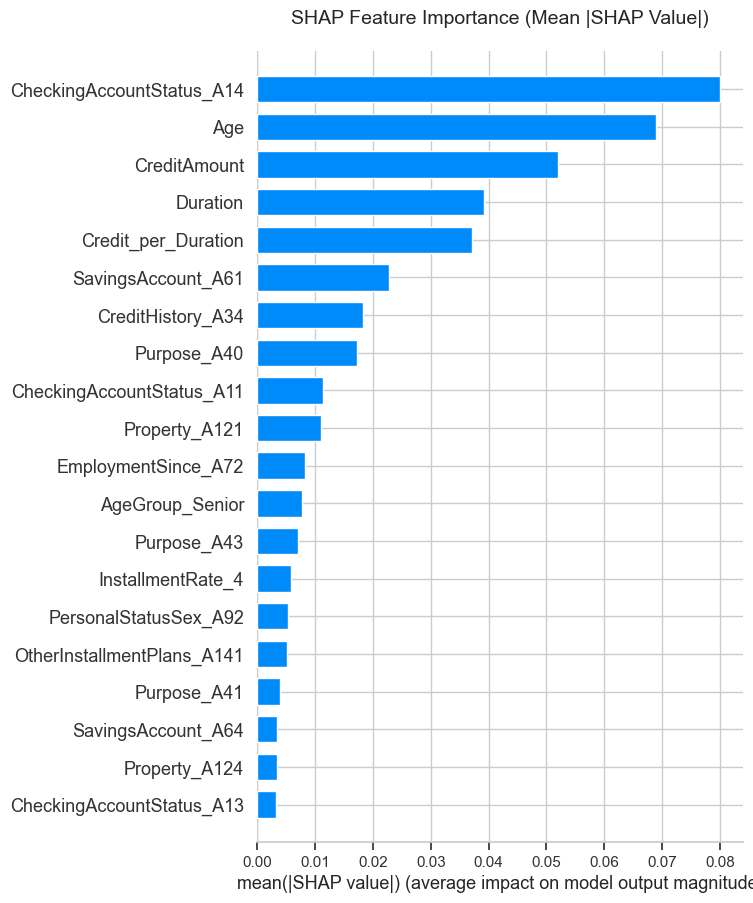

  Generating SHAP beeswarm plot...


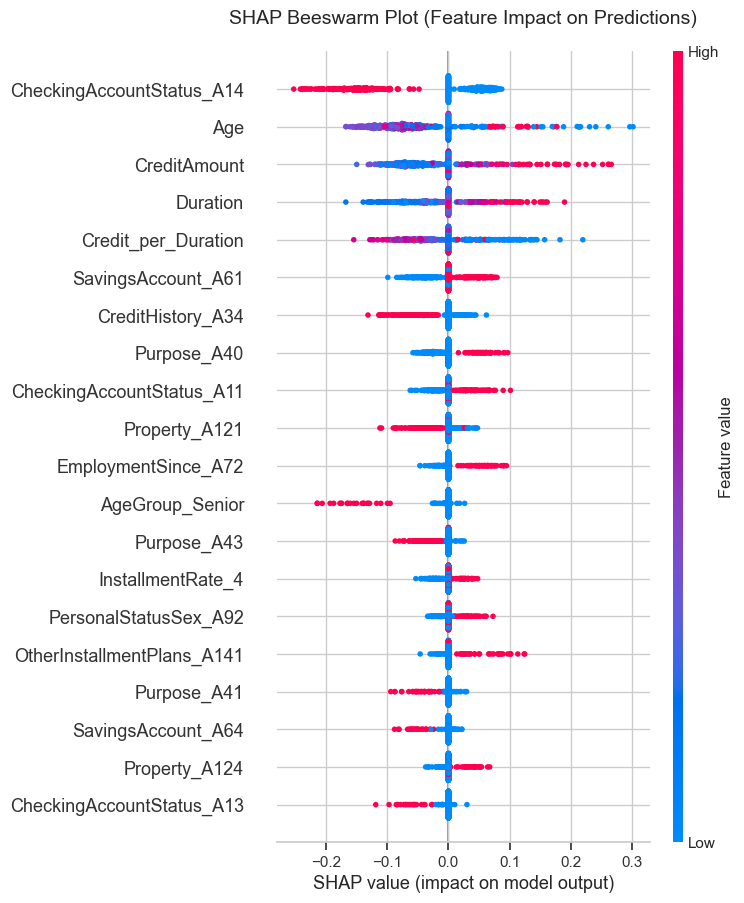


  Top 10 Most Important Features (by mean |SHAP value|):
  --------------------------------------------------
   1. CheckingAccountStatus_A14               : 0.0801
   2. Age                                     : 0.0689
   3. CreditAmount                            : 0.0520
   4. Duration                                : 0.0393
   5. Credit_per_Duration                     : 0.0371
   6. SavingsAccount_A61                      : 0.0228
   7. CreditHistory_A34                       : 0.0184
   8. Purpose_A40                             : 0.0172
   9. CheckingAccountStatus_A11               : 0.0113
  10. Property_A121                           : 0.0111

✅ SHAP analysis complete.

  Generating SHAP waterfall plot for sample 0...


  0%|          | 0/1 [00:00<?, ?it/s]

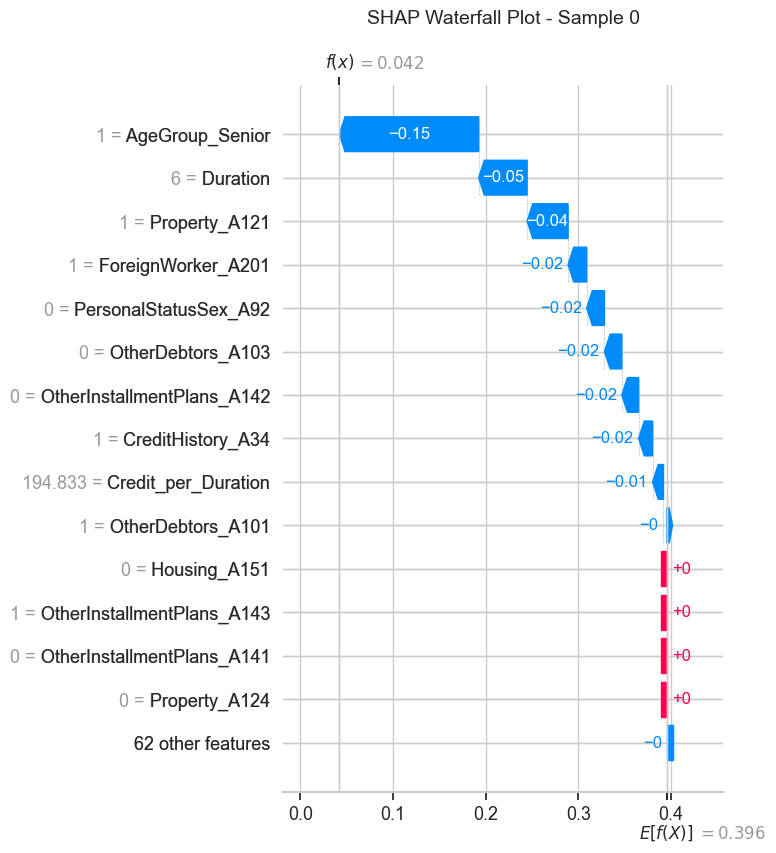

In [15]:
# %% [markdown]
# ## 9. SHAP Explainability (KernelExplainer)



# Load model and data
model = joblib.load('../models/xgb_cwgan_balanced.pkl')
X_test = pd.read_csv('../data/processed/german_balanced_cwgan_improved.csv').drop('Class', axis=1)

# Run SHAP analysis
shap_values, explainer = shap_explain(
    model=model,
    X_train=X_train_gan.values,
    X_test=X_test.values,
    feature_names=X_test.columns.tolist(),
    max_display=20,
    save_path='../figures/shap'
)

# Optional: Waterfall plot for a specific sample
shap_waterfall_plot(
    model=model,
    X_sample=X_test.values,
    feature_names=X_test.columns.tolist(),
    sample_idx=0,
    save_path='../figures/shap'
)